In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

%matplotlib inline

/root/anaconda3/envs/test/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
from load_datas import load_mat
data_cora = load_mat('cora',path='data_CE/')
y_idx = torch.nonzero(data_cora.y==1).reshape(-1)
E = data_cora.edge_index
y = data_cora.y
x = data_cora.x
data_cora


Data(x=[2708, 1433], edge_index=[2, 11606], y=[2708], str_y=[2708], attr_y=[2708])

In [ ]:
from load_datas import load_truth
data = load_truth('weibo')
y_idx = torch.nonzero(data.y==1).reshape(-1)
E = data.edge_index
y = data.y
x = data.x
data

Data(x=[8405, 400], edge_index=[2, 407963], y=[8405], str_y=[8405], attr_y=[8405])

In [ ]:
from torch_geometric.utils import to_networkx
# Function to compute average clustering coefficients
def compute_avg_clustering_pyg(data):
    # Convert the PyTorch Geometric Data object to a NetworkX graph
    G = to_networkx(data, to_undirected=True)
    
    # Compute clustering coefficients for all nodes
    clustering_coefficients = nx.clustering(G)
    
    # Get the structural anomaly labels (0 = normal, 1 = anomalous)
    labels = data.y.numpy()  # Convert to NumPy array for easier indexing
    
    # Separate nodes by their labels
    normal_nodes = [node for node, label in enumerate(labels) if label == 0]
    anomalous_nodes = [node for node, label in enumerate(labels) if label == 1]
    
    # Calculate average clustering coefficients for normal and anomalous nodes
    normal_clustering = [clustering_coefficients[node] for node in normal_nodes]
    anomalous_clustering = [clustering_coefficients[node] for node in anomalous_nodes]
    
    avg_clustering_normal = np.mean(normal_clustering) if normal_clustering else 0
    avg_clustering_anomalous = np.mean(anomalous_clustering) if anomalous_clustering else 0
    
    return avg_clustering_normal, avg_clustering_anomalous


In [ ]:
def extract_subgraph(data, normal_to_anomalous_ratio=1):
    edge_index = data['edge_index']  
    y = data['y'].flatten()  

    edges = torch.tensor(edge_index, dtype=torch.long)
    graph = nx.Graph()
    graph.add_edges_from(edges.t().tolist())

    anomalous_nodes = np.where(y == 1)[0]
    normal_nodes = np.where(y == 0)[0]

    # 计算正常节点和异常节点的数量
    num_anomalous = len(anomalous_nodes)
    num_normal = len(normal_nodes)

    # 根据比例选择正常节点
    selected_normal_count = int(normal_to_anomalous_ratio * num_anomalous)
    selected_normal_nodes = np.random.choice(normal_nodes, size=selected_normal_count, replace=False)

    # 选择所有异常节点
    selected_anomalous_nodes = anomalous_nodes

    # 合并正常节点和异常节点
    selected_nodes = np.concatenate([selected_normal_nodes, selected_anomalous_nodes])

    # 提取包含选择节点的子图
    subgraph = graph.subgraph(selected_nodes)

    return subgraph, selected_anomalous_nodes, selected_normal_nodes

def extract_connected_subgraph(data, normal_to_anomalous_ratio=1):
    edge_index = data['edge_index']
    y = data['y'].flatten()

    edges = torch.tensor(edge_index, dtype=torch.long)
    graph = nx.Graph()
    graph.add_edges_from(edges.t().tolist())

    anomalous_nodes = np.where(y == 1)[0]
    normal_nodes = np.where(y == 0)[0]

    num_anomalous = len(anomalous_nodes)
    num_normal = len(normal_nodes)

    # 从异常节点开始，使用 BFS 扩展子图
    selected_nodes = set(anomalous_nodes)
    queue = list(anomalous_nodes)

    # 计算需要选择的正常节点数量
    selected_normal_count = int(normal_to_anomalous_ratio * num_anomalous)

    while queue and len(selected_nodes) < (num_anomalous + selected_normal_count):
        node = queue.pop(0)
        for neighbor in graph.neighbors(node):
            if neighbor not in selected_nodes:
                selected_nodes.add(neighbor)
                queue.append(neighbor)

    # 提取子图
    subgraph = graph.subgraph(selected_nodes)

    # 获取选择的异常节点和正常节点
    selected_anomalous_nodes = [node for node in selected_nodes if y[node] == 1]
    selected_normal_nodes = [node for node in selected_nodes if y[node] == 0]

    return subgraph, selected_anomalous_nodes, selected_normal_nodes

# 使用 BFS 计算子图中最短路径的平均值
def Sub_SP(graph, nodes_a, nodes_b):
    paths = []
    for node_a in nodes_a:
        lengths = nx.single_source_shortest_path_length(graph, node_a)
        for node_b in nodes_b:
            if node_b in lengths:
                paths.append(lengths[node_b])
    return np.mean(paths) if paths else None


In [ ]:
# 计算余弦相似度
from itertools import combinations
def cosine_similarity(x_i, x_j):
    dot_product = torch.matmul(x_i, x_j.T)  # 使用矩阵乘法提高效率
    norm_i = torch.norm(x_i, dim=1, keepdim=True)
    norm_j = torch.norm(x_j, dim=1, keepdim=True)
    return dot_product / (norm_i * norm_j.T)  # 注意这里是矩阵运算

# 计算每个节点的邻居之间的相似度
def compute_neighbor_cosine_similarity(x, E):
    # 找到每个节点的邻居
    neighbors = {i: [] for i in range(x.size(0))}
    for i, j in E.t():
        neighbors[i.item()].append(j.item())
    
    cos_sim_avg = {}
    
    # 对每个节点的邻居计算相似度
    for i, neighs in neighbors.items():
        if len(neighs) > 1:  # 至少需要两个邻居来计算相似度
            neigh_features = x[neighs]
            
            # 计算每对邻居之间的相似度
            cos_sims = []
            for a, b in combinations(range(neigh_features.size(0)), 2):  # 计算每对邻居之间的相似度
                cos_sim = cosine_similarity(neigh_features[a].unsqueeze(0), neigh_features[b].unsqueeze(0)).item()
                cos_sims.append(cos_sim)
            
            # 计算平均相似度
            cos_sim_avg[i] = sum(cos_sims) / len(cos_sims)
        else:
            cos_sim_avg[i] = None  # 如果没有足够的邻居来计算，返回None或0
    
    return cos_sim_avg

# 计算每个数据集的平均相似度
def calculate_avg_similarity_for_normal_and_anomalous_nodes(datasets):
    avg_normal_similarities = []
    avg_anomalous_similarities = []
    
    for dataset_name, data in datasets.items():
        x = data.x  # 节点特征
        E = data.edge_index  # 邻接矩阵
        
        # 计算邻居之间的相似度
        cos_sim_avg = compute_neighbor_cosine_similarity(x, E)
        
        # 获取节点标签
        labels = data.y
        
        # 分类正常节点和异常节点
        normal_nodes = [i for i, label in enumerate(labels) if label == 0]
        anomalous_nodes = [i for i, label in enumerate(labels) if label == 1]
        
        # 计算正常节点的平均相似度
        normal_similarities = [cos_sim_avg[i] for i in normal_nodes if cos_sim_avg[i] is not None]
        avg_normal_similarity = sum(normal_similarities) / len(normal_similarities) if normal_similarities else 0
        
        # 计算异常节点的平均相似度
        anomalous_similarities = [cos_sim_avg[i] for i in anomalous_nodes if cos_sim_avg[i] is not None]
        avg_anomalous_similarity = sum(anomalous_similarities) / len(anomalous_similarities) if anomalous_similarities else 0
        
        avg_normal_similarities.append(avg_normal_similarity)
        avg_anomalous_similarities.append(avg_anomalous_similarity)
    
    return avg_normal_similarities, avg_anomalous_similarities

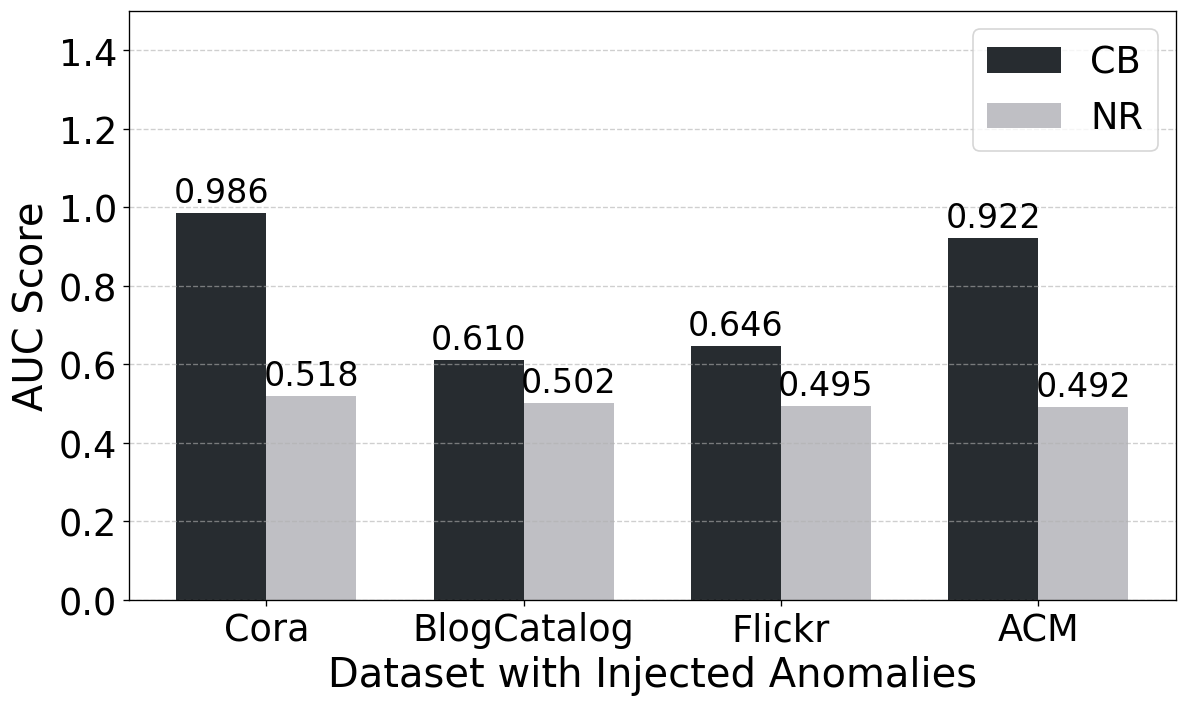

In [ ]:
import scipy.io as sio
import torch
from torch_geometric.data import Data
import torch_geometric.utils as utils
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from load_datas import load_mat, load_truth

# Function to compute clustering coefficients and return as anomaly scores
def compute_clustering_scores(data):
    """
    计算图中每个节点的聚集系数并返回作为异常分数
    """
    if not isinstance(data, Data):
        return None
    
    # Convert to NetworkX graph
    G = to_networkx(data, to_undirected=True)
    
    # Compute clustering coefficients for all nodes
    clustering_coefficients = nx.clustering(G)
    
    # Convert to array in node order
    scores = np.array([clustering_coefficients[node] for node in range(data.num_nodes)])
    
    # 聚集系数越低越可能是异常点，所以取负值作为分数
    return -scores

# 初始化数据集字典
datasets = {
    'Cora(Tradition)': load_mat('cora',path='./data_Trad'),
    'BlogCatalog(Tradition)': load_mat('BlogCatalog',path='./data_Trad'), 
    'Flickr(Tradition)': load_mat('Flickr',path='./data_Trad'),
    'ACM(Tradition)': load_mat('ACM',path='./data_Trad'),
    'Cora(Recent)': load_mat('cora',path='./data_opts'),
    'BlogCatalog(Recent)': load_mat('BlogCatalog',path='./data_opts'),
    'Flickr(Recent)': load_mat('Flickr',path='./data_opts'),
    'ACM(Recent)': load_mat('ACM',path='./data_opts'),
}

# 存储AUC结果
auc_results = []

# 对每个数据集进行AUC计算
#for dataset_name, data in datasets.items():
    # 如果是图数据集，获取标签和边列表
    #if isinstance(data, Data):
        #y_true = data.str_y.cpu().numpy()  # 二分类标签
        #edge_index = data.edge_index  # 图的边列表

        # 计算聚集系数作为异常分数
        #scores = compute_clustering_scores(data)
        #if scores is not None:
            # 计算AUC
            #auc = roc_auc_score(y_true, scores)
            #auc_results.append((dataset_name, auc))
# 对每个数据集进行AUC计算
for dataset_name, data in datasets.items():
    # 如果是图数据集，获取标签和边列表
    if isinstance(data, Data):
        y_true = data.str_y.cpu().numpy()  # 二分类标签
        edge_index = data.edge_index  # 图的边列表

        # 计算节点的度数
        deg = utils.degree(edge_index[0], num_nodes=data.x.size(0), dtype=data.x.dtype)
        score = deg.detach().numpy()  # 度数作为异常分数

    # 计算AUC
    auc = roc_auc_score((y_true > 0).astype(int), score)  # 假设异常节点标签为1
    auc_results.append((dataset_name, auc))

# 准备绘图数据
base_datasets = ['Cora', 'BlogCatalog', 'Flickr', 'ACM']
tradition_scores = []
recent_scores = []

for base in base_datasets:
    tradition_scores.append(next(auc for name, auc in auc_results if base in name and 'Trad' in name))
    recent_scores.append(next(auc for name, auc in auc_results if base in name and 'Recent' in name))

x = np.arange(len(base_datasets))  # 标签位置
width = 0.35  # 柱状图宽度

plt.figure(figsize=(10, 6), dpi=120)

bars_tradition = plt.bar(x - width/2, tradition_scores, width,
                         label='CB', color="#272C30")
bars_recent = plt.bar(x + width/2, recent_scores, width,
                      label='NR', color="#BFBFC4")

# 字体变大
plt.ylabel('AUC Score', fontsize=24)
plt.xlabel('Dataset with Injected Anomalies', fontsize=24)
plt.xticks(x, base_datasets, fontsize=22)
plt.yticks(fontsize=22)

# 设置 y 轴范围：最小 0，最大 1.5
plt.ylim(0, 1.5)  # 关键修改
# 图例放图内右上角，不重叠柱子
plt.legend(fontsize=22, frameon=True)

# 在每个柱子上方显示AUC值
for bars in [bars_tradition, bars_recent]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=20)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

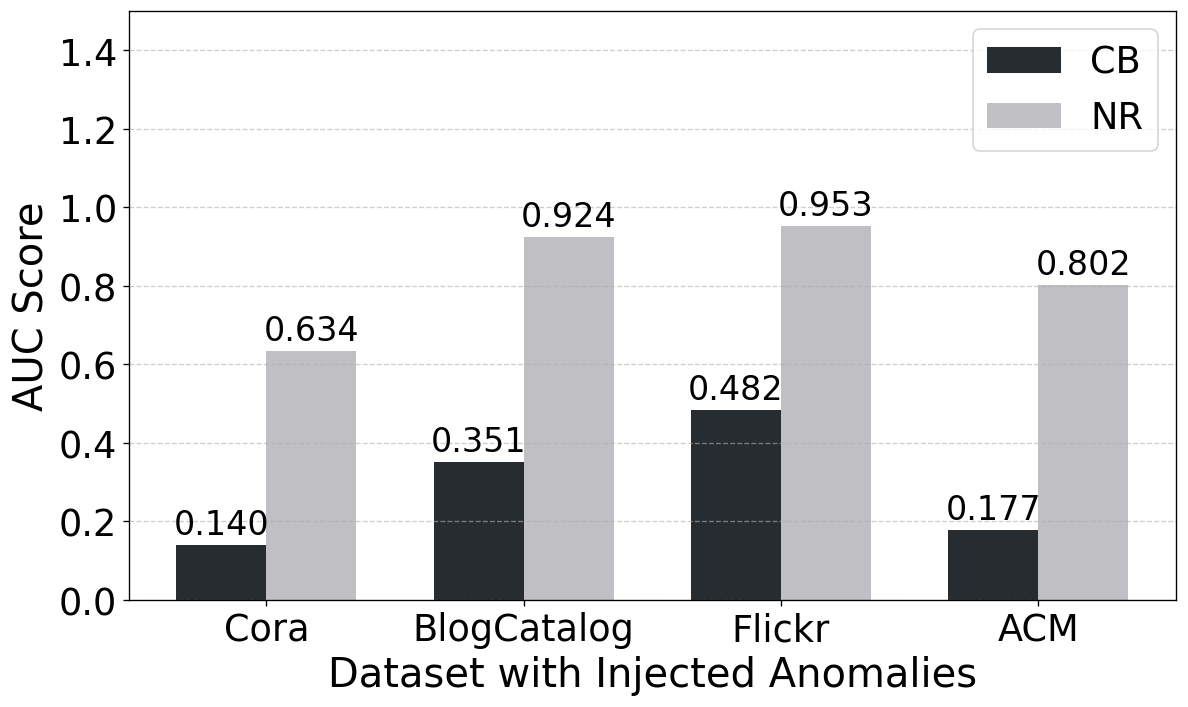

In [ ]:
import scipy.io as sio
import torch
from torch_geometric.data import Data
import torch_geometric.utils as utils
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from load_datas import load_mat, load_truth
import networkx as nx

# Function to compute clustering coefficients and return as anomaly scores
def compute_clustering_scores(data):
    """
    计算图中每个节点的聚集系数并返回作为异常分数
    """
    if not isinstance(data, Data):
        return None
    
    # Convert to NetworkX graph
    G = to_networkx(data, to_undirected=True)
    
    # Compute clustering coefficients for all nodes
    clustering_coefficients = nx.clustering(G)
    
    # Convert to array in node order
    scores = np.array([clustering_coefficients[node] for node in range(data.num_nodes)])
    
    # 聚集系数越低越可能是异常点，所以取负值作为分数
    return -scores

# 初始化数据集字典
datasets = {
    'Cora(Tradition)': load_mat('cora',path='./data_Trad'),
    'BlogCatalog(Tradition)': load_mat('BlogCatalog',path='./data_Trad'), 
    'Flickr(Tradition)': load_mat('Flickr',path='./data_Trad'),
    'ACM(Tradition)': load_mat('ACM',path='./data_Trad'),
    'Cora(Recent)': load_mat('cora',path='./data_opts'),
    'BlogCatalog(Recent)': load_mat('BlogCatalog',path='./data_opts'),
    'Flickr(Recent)': load_mat('Flickr',path='./data_opts'),
    'ACM(Recent)': load_mat('ACM',path='./data_opts'),
}

# 存储AUC结果
auc_results = []

# 对每个数据集进行AUC计算
for dataset_name, data in datasets.items():
    # 如果是图数据集，获取标签和边列表
    if isinstance(data, Data):
        y_true = data.str_y.cpu().numpy()  # 二分类标签
        edge_index = data.edge_index  # 图的边列表

        # 计算聚集系数作为异常分数
        scores = compute_clustering_scores(data)
        if scores is not None:
            # 计算AUC
            auc = roc_auc_score(y_true, scores)
            auc_results.append((dataset_name, auc))



# 准备绘图数据
base_datasets = ['Cora', 'BlogCatalog', 'Flickr', 'ACM']
tradition_scores = []
recent_scores = []

for base in base_datasets:
    tradition_scores.append(next(auc for name, auc in auc_results if base in name and 'Trad' in name))
    recent_scores.append(next(auc for name, auc in auc_results if base in name and 'Recent' in name))

x = np.arange(len(base_datasets))  # 标签位置
width = 0.35  # 柱状图宽度

plt.figure(figsize=(10, 6), dpi=120)

bars_tradition = plt.bar(x - width/2, tradition_scores, width,
                         label='CB', color="#272C30")
bars_recent = plt.bar(x + width/2, recent_scores, width,
                      label='NR', color="#BFBFC4")

# 字体变大
plt.ylabel('AUC Score', fontsize=24)
plt.xlabel('Dataset with Injected Anomalies', fontsize=24)
plt.xticks(x, base_datasets, fontsize=22)
plt.yticks(fontsize=22)
# 设置 y 轴范围：最小 0，最大 1.5
plt.ylim(0, 1.5)  # 关键修改
# 图例放图内右上角，不重叠柱子
plt.legend(fontsize=22, frameon=True)

# 在每个柱子上方显示AUC值
for bars in [bars_tradition, bars_recent]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=20)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

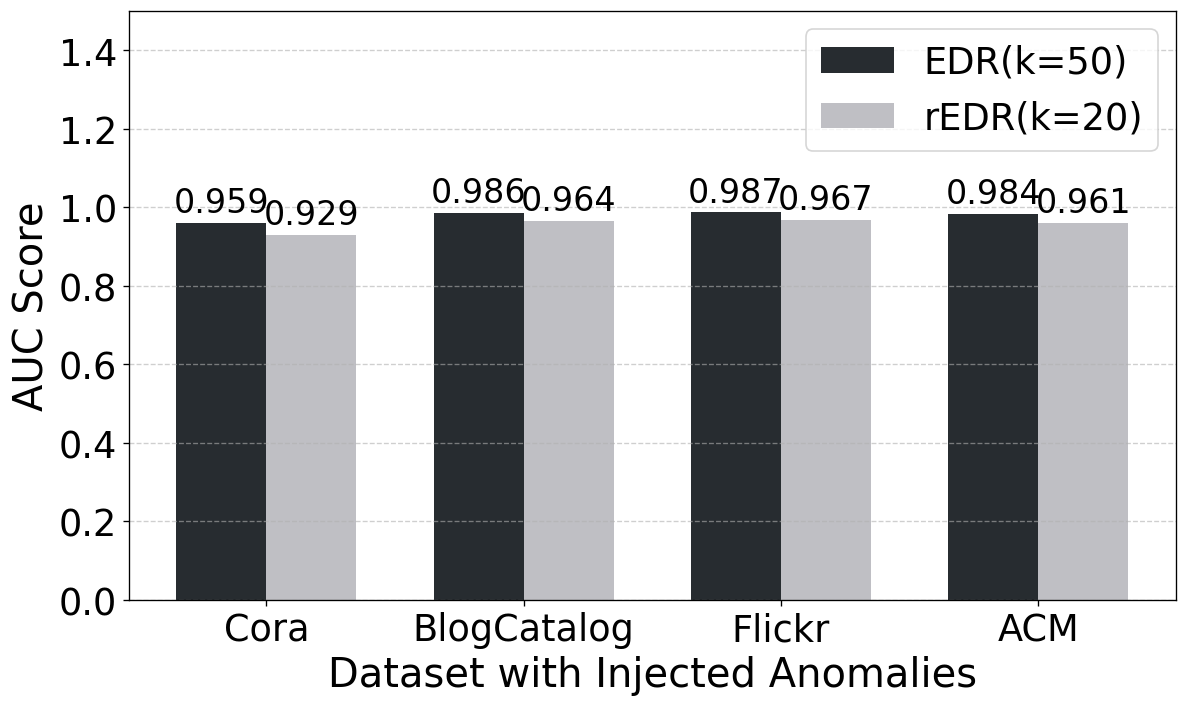

In [ ]:
import scipy.io as sio
import torch
from torch_geometric.data import Data
import torch_geometric.utils as utils
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from load_datas import load_mat, load_truth

# Function to compute clustering coefficients and return as anomaly scores
def compute_clustering_scores(data):
    """
    计算图中每个节点的聚集系数并返回作为异常分数
    """
    if not isinstance(data, Data):
        return None
    
    # Convert to NetworkX graph
    G = to_networkx(data, to_undirected=True)
    
    # Compute clustering coefficients for all nodes
    clustering_coefficients = nx.clustering(G)
    
    # Convert to array in node order
    scores = np.array([clustering_coefficients[node] for node in range(data.num_nodes)])
    
    # 聚集系数越低越可能是异常点，所以取负值作为分数
    return -scores

# 初始化数据集字典
datasets = {
    'Cora(Tradition)': load_mat('cora',path='./data_Trad'),
    'BlogCatalog(Tradition)': load_mat('BlogCatalog',path='./data_Trad'), 
    'Flickr(Tradition)': load_mat('Flickr',path='./data_Trad'),
    'ACM(Tradition)': load_mat('ACM',path='./data_Trad'),
    'Cora(Recent)': load_mat('cora',path='./data_opts'),
    'BlogCatalog(Recent)': load_mat('BlogCatalog',path='./data_opts'),
    'Flickr(Recent)': load_mat('Flickr',path='./data_opts'),
    'ACM(Recent)': load_mat('ACM',path='./data_opts'),
}

# 存储AUC结果
auc_results = []

# 对每个数据集进行AUC计算
for dataset_name, data in datasets.items():
    # 如果是图数据集，获取标签和边列表
    if isinstance(data, Data):
        y_true = data.attr_y.cpu().numpy()  # 二分类标签
        edge_index = data.edge_index  # 图的边列表

        norm = torch.norm(data.x, dim=-1).numpy()
    # 如果是标签数据集，直接获取标签并计算度数
    else:
        y_true = data
        score = np.random.rand(len(y_true))  # 为示例生成随机的分数

    # 计算AUC
    auc = roc_auc_score((y_true > 0).astype(int), norm)  # 假设异常节点标签为1
    auc_results.append((dataset_name, auc))
# 准备绘图数据
base_datasets = ['Cora', 'BlogCatalog', 'Flickr', 'ACM']
tradition_scores = []
recent_scores = []

for base in base_datasets:
    tradition_scores.append(next(auc for name, auc in auc_results if base in name and 'Trad' in name))
    recent_scores.append(next(auc for name, auc in auc_results if base in name and 'Recent' in name))

x = np.arange(len(base_datasets))  # 标签位置
width = 0.35  # 柱状图宽度

plt.figure(figsize=(10, 6), dpi=120)

bars_tradition = plt.bar(x - width/2, tradition_scores, width,
                         label='EDR(k=50)', color="#272C30")
bars_recent = plt.bar(x + width/2, recent_scores, width,
                      label='rEDR(k=20)', color="#BFBFC4")

# 字体变大
plt.ylabel('AUC Score', fontsize=24)
plt.xlabel('Dataset with Injected Anomalies', fontsize=24)
plt.xticks(x, base_datasets, fontsize=22)
plt.yticks(fontsize=22)

# 设置 y 轴范围：最小 0，最大 1.5
plt.ylim(0, 1.5)  # 关键修改
# 图例放图内右上角，不重叠柱子
plt.legend(fontsize=22, frameon=True)

# 在每个柱子上方显示AUC值
for bars in [bars_tradition, bars_recent]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=20)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


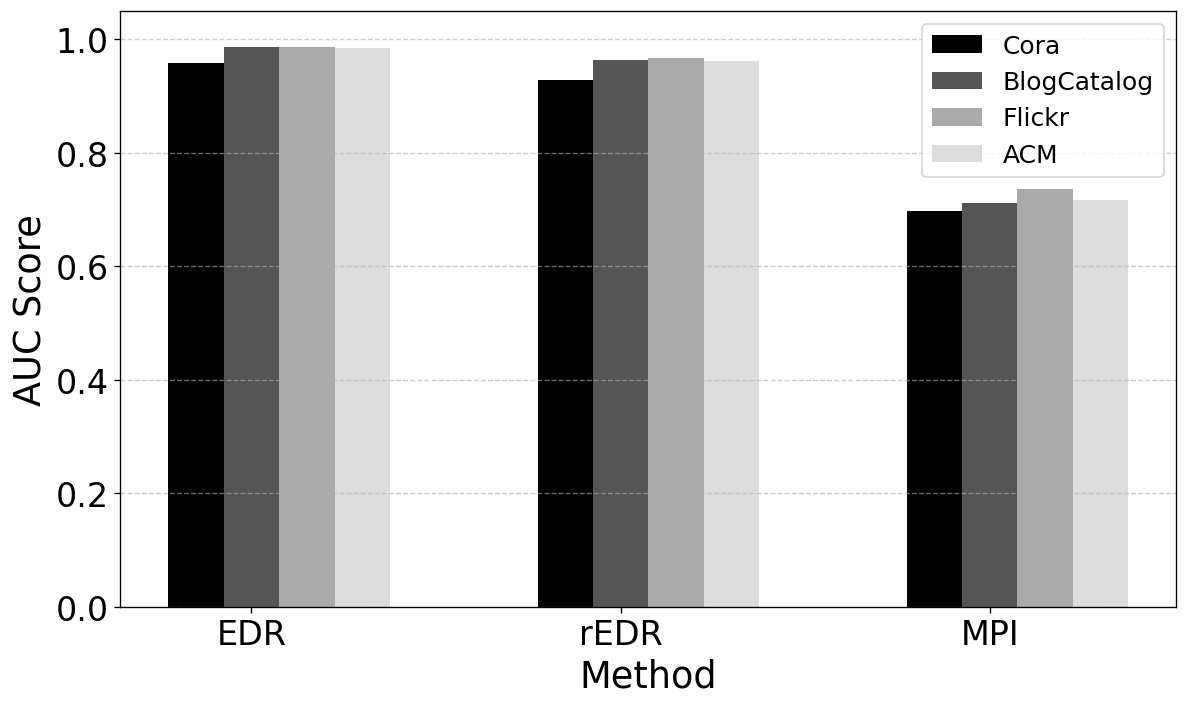

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# 数据
methods = ['EDR', 'rEDR', 'MPI']
datasets = ['Cora', 'BlogCatalog', 'Flickr', 'ACM']
scores = {
    'Cora': [0.959, 0.929, 0.698],
    'BlogCatalog': [0.986, 0.964, 0.712],
    'Flickr': [0.987, 0.967, 0.736],
    'ACM': [0.984, 0.961, 0.717]
}

x = np.arange(len(methods))  # 方法位置
width = 0.15  # 每个柱子宽度

plt.figure(figsize=(10, 6), dpi=120)

# 使用蓝色渐变为每个数据集上色
colors = ['#000000', '#555555', '#AAAAAA', '#DDDDDD']
bars_list = []
for i, dataset in enumerate(datasets):
    bars = plt.bar(x + (i - 1)*width, scores[dataset], width,
                   label=dataset, color=colors[i])
    bars_list.append(bars)

# 字体大小
plt.ylabel('AUC Score', fontsize=22)
plt.xlabel('Method', fontsize=22)
plt.xticks(x, methods, fontsize=20)
plt.yticks(fontsize=20)

# y轴范围
plt.ylim(0, 1.05)

# 图例
plt.legend(fontsize=15, frameon=True)

# 在柱子上方显示数值
#for bars in bars_list:
    #for bar in bars:
        #height = bar.get_height()
        #plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 #f'{height:.3f}', ha='center', va='bottom', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
